# ___Phylogenetic PCA___
---------------------------

In [1]:
print(R.version$version.string)

[1] "R version 4.6.0 (2026-04-24 ucrt)"


In [3]:
suppressPackageStartupMessages({  
    library("ggplot2")
    library("ape")
    library("phytools")
    library("phylobase")
    library("adephylo")
    library("readxl")
})

In [4]:
states <- as.data.frame(readxl::read_xlsx("../../data/chapter2/FRED/subsets/final.xlsx", sheet = "final")[, c("binominal", "state")])
states$binominal <- gsub(states$binominal, pattern = ' ', replacement = '_')
data <- read.csv("../../data/chapter2/FRED/subsets/continuous_raw.csv")
phylogeny <- ape::read.tree("../../data/chapter2/uphylomaker/FRED4_1301.tre")

stopifnot(all(states$binominal %in% data$binominal))
stopifnot(all(states$binominal %in% phylogeny$tip.label))

In [6]:
averages <- aggregate(x = data[, c("F00679", "F00727", "F00709")], by = list(data$binominal), FUN = mean, simplify = TRUE) # species averages
averages[, -1] <- apply(averages[, -1], FUN = log, MARGIN = 2) |> apply(FUN = scale, MARGIN = 2, center = TRUE, scale = TRUE) # log transform and standardize the values (Z scores)

In [7]:
rownames(averages) <- averages$`Group.1` # set the species names as the row names
averages <- averages[, -1] # drop that column
head(averages)

,F00679,F00727,F00709
,<dbl>,<dbl>,<dbl>
Abies_alba,0.63510885,0.02600399,-0.15239477
Abies_nephrolepis,0.01896267,-0.12243122,0.05612151
Acacia_auriculiformis,0.37989941,0.16110758,0.12948648
Acacia_crassicarpa,-1.28984464,1.09570276,0.44532467
Acacia_mangium,-1.05031695,1.01870522,0.11186091
Acer_barbinerve,-1.05244676,1.34409226,-0.87602769


## ___`phytools::phyl.pca`___
---------------------

In [8]:
# https://besjournals.onlinelibrary.wiley.com/doi/10.1111/1365-2435.14739
# https://github.com/dgkontopoulos/Kontopoulos_et_al_torpor_evolution_2025/blob/main/Code/run_phylogenetic_pca.R

pcomps <- phytools::phyl.pca(tree = phylogeny, method = "lambda", Y = averages) # phylogenetic PCA using phytools

In [12]:
pcomps

Phylogenetic pca
Standard deviations:
       PC1        PC2        PC3 
0.10261660 0.07513227 0.02080151 
Loads:
              PC1         PC2        PC3
F00679  0.8412529 -0.51955366 -0.1495244
F00727 -0.9756556 -0.07953914 -0.2043764
F00709  0.4807227  0.86859345 -0.1202128
lambda:
[1] 0.8032579

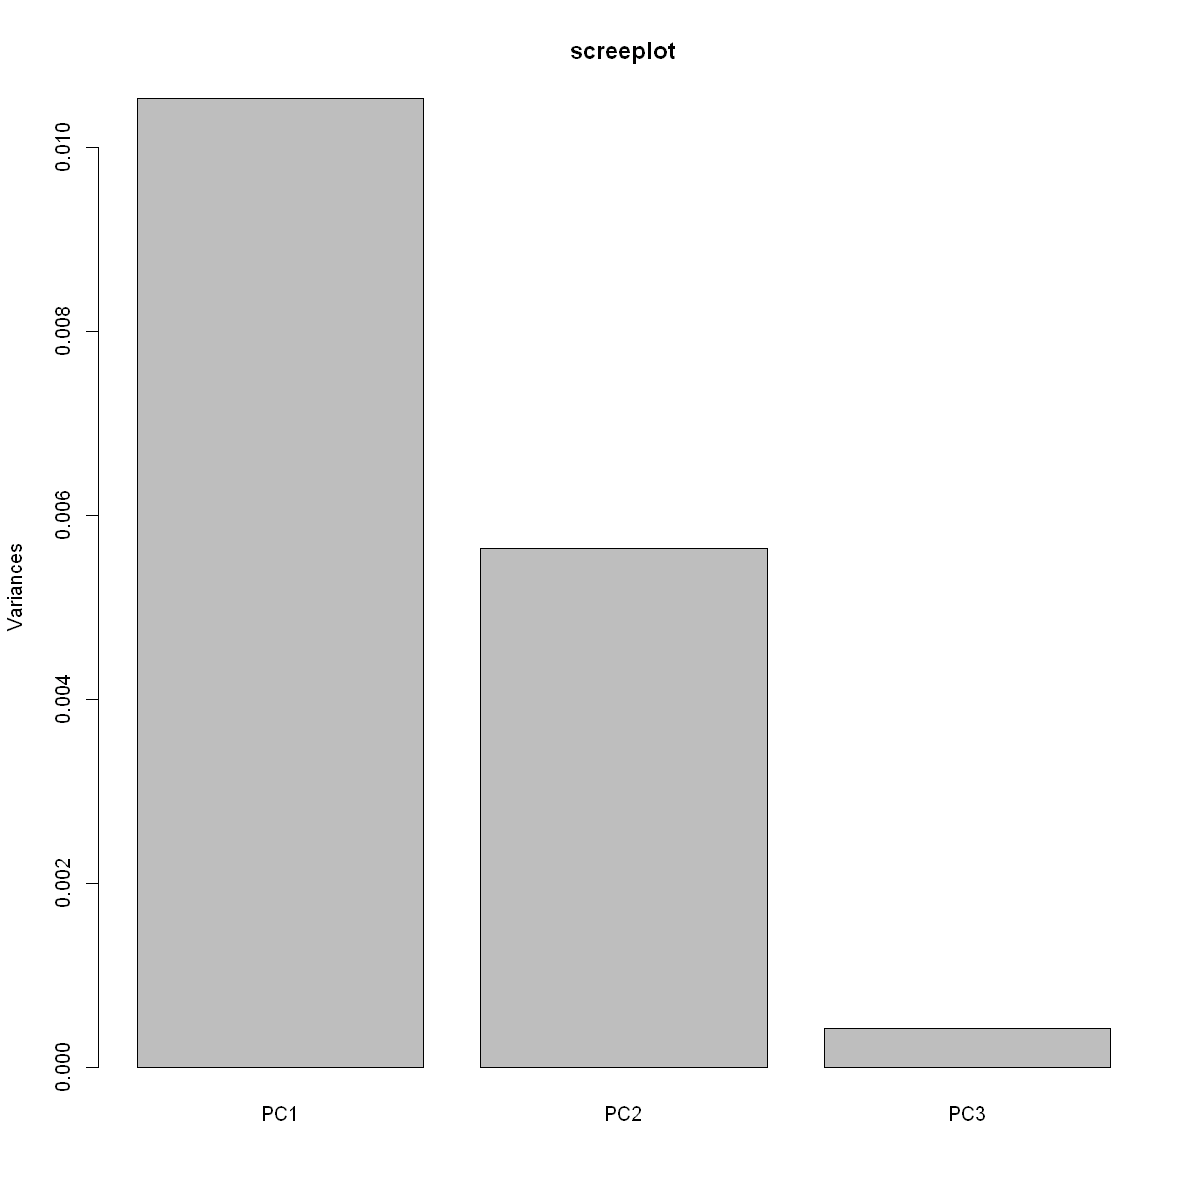

In [19]:
plot(pcomps)

In [38]:
str(pcomps$S) # these are aour loadings

 num [1:1301, 1:3] 0.497 0.28 0.338 -1.263 -1.171 ...
 - attr(*, "dimnames")=List of 2
  ..$ : chr [1:1301] "Abies_alba" "Abies_nephrolepis" "Acacia_auriculiformis" "Acacia_crassicarpa" ...
  ..$ : chr [1:3] "PC1" "PC2" "PC3"


In [52]:
ppca <- as.data.frame(pcomps$S)
ppca$binominal <- rownames(ppca)
rownames(ppca) <- NULL
ppca <- merge(x = ppca, y = states, by = "binominal") # merge the mycorrhizal states column

head(ppca)

,binominal,PC1,PC2,PC3,state
,<chr>,<dbl>,<dbl>,<dbl>,<chr>
1,Abies_alba,0.4974335,0.1468412,-0.38632880,EcM
2,Abies_nephrolepis,0.2801755,0.6636568,-0.02459863,EcM
3,Acacia_auriculiformis,0.3377686,0.5101453,-0.45953456,EcMAM
4,Acacia_crassicarpa,-1.2628092,1.5979085,-0.33229710,EcMAM
5,Acacia_mangium,-1.1709656,1.1951401,-0.27030834,EcMAM
6,Acer_barbinerve,-1.7345532,0.3404099,-0.08697691,AM


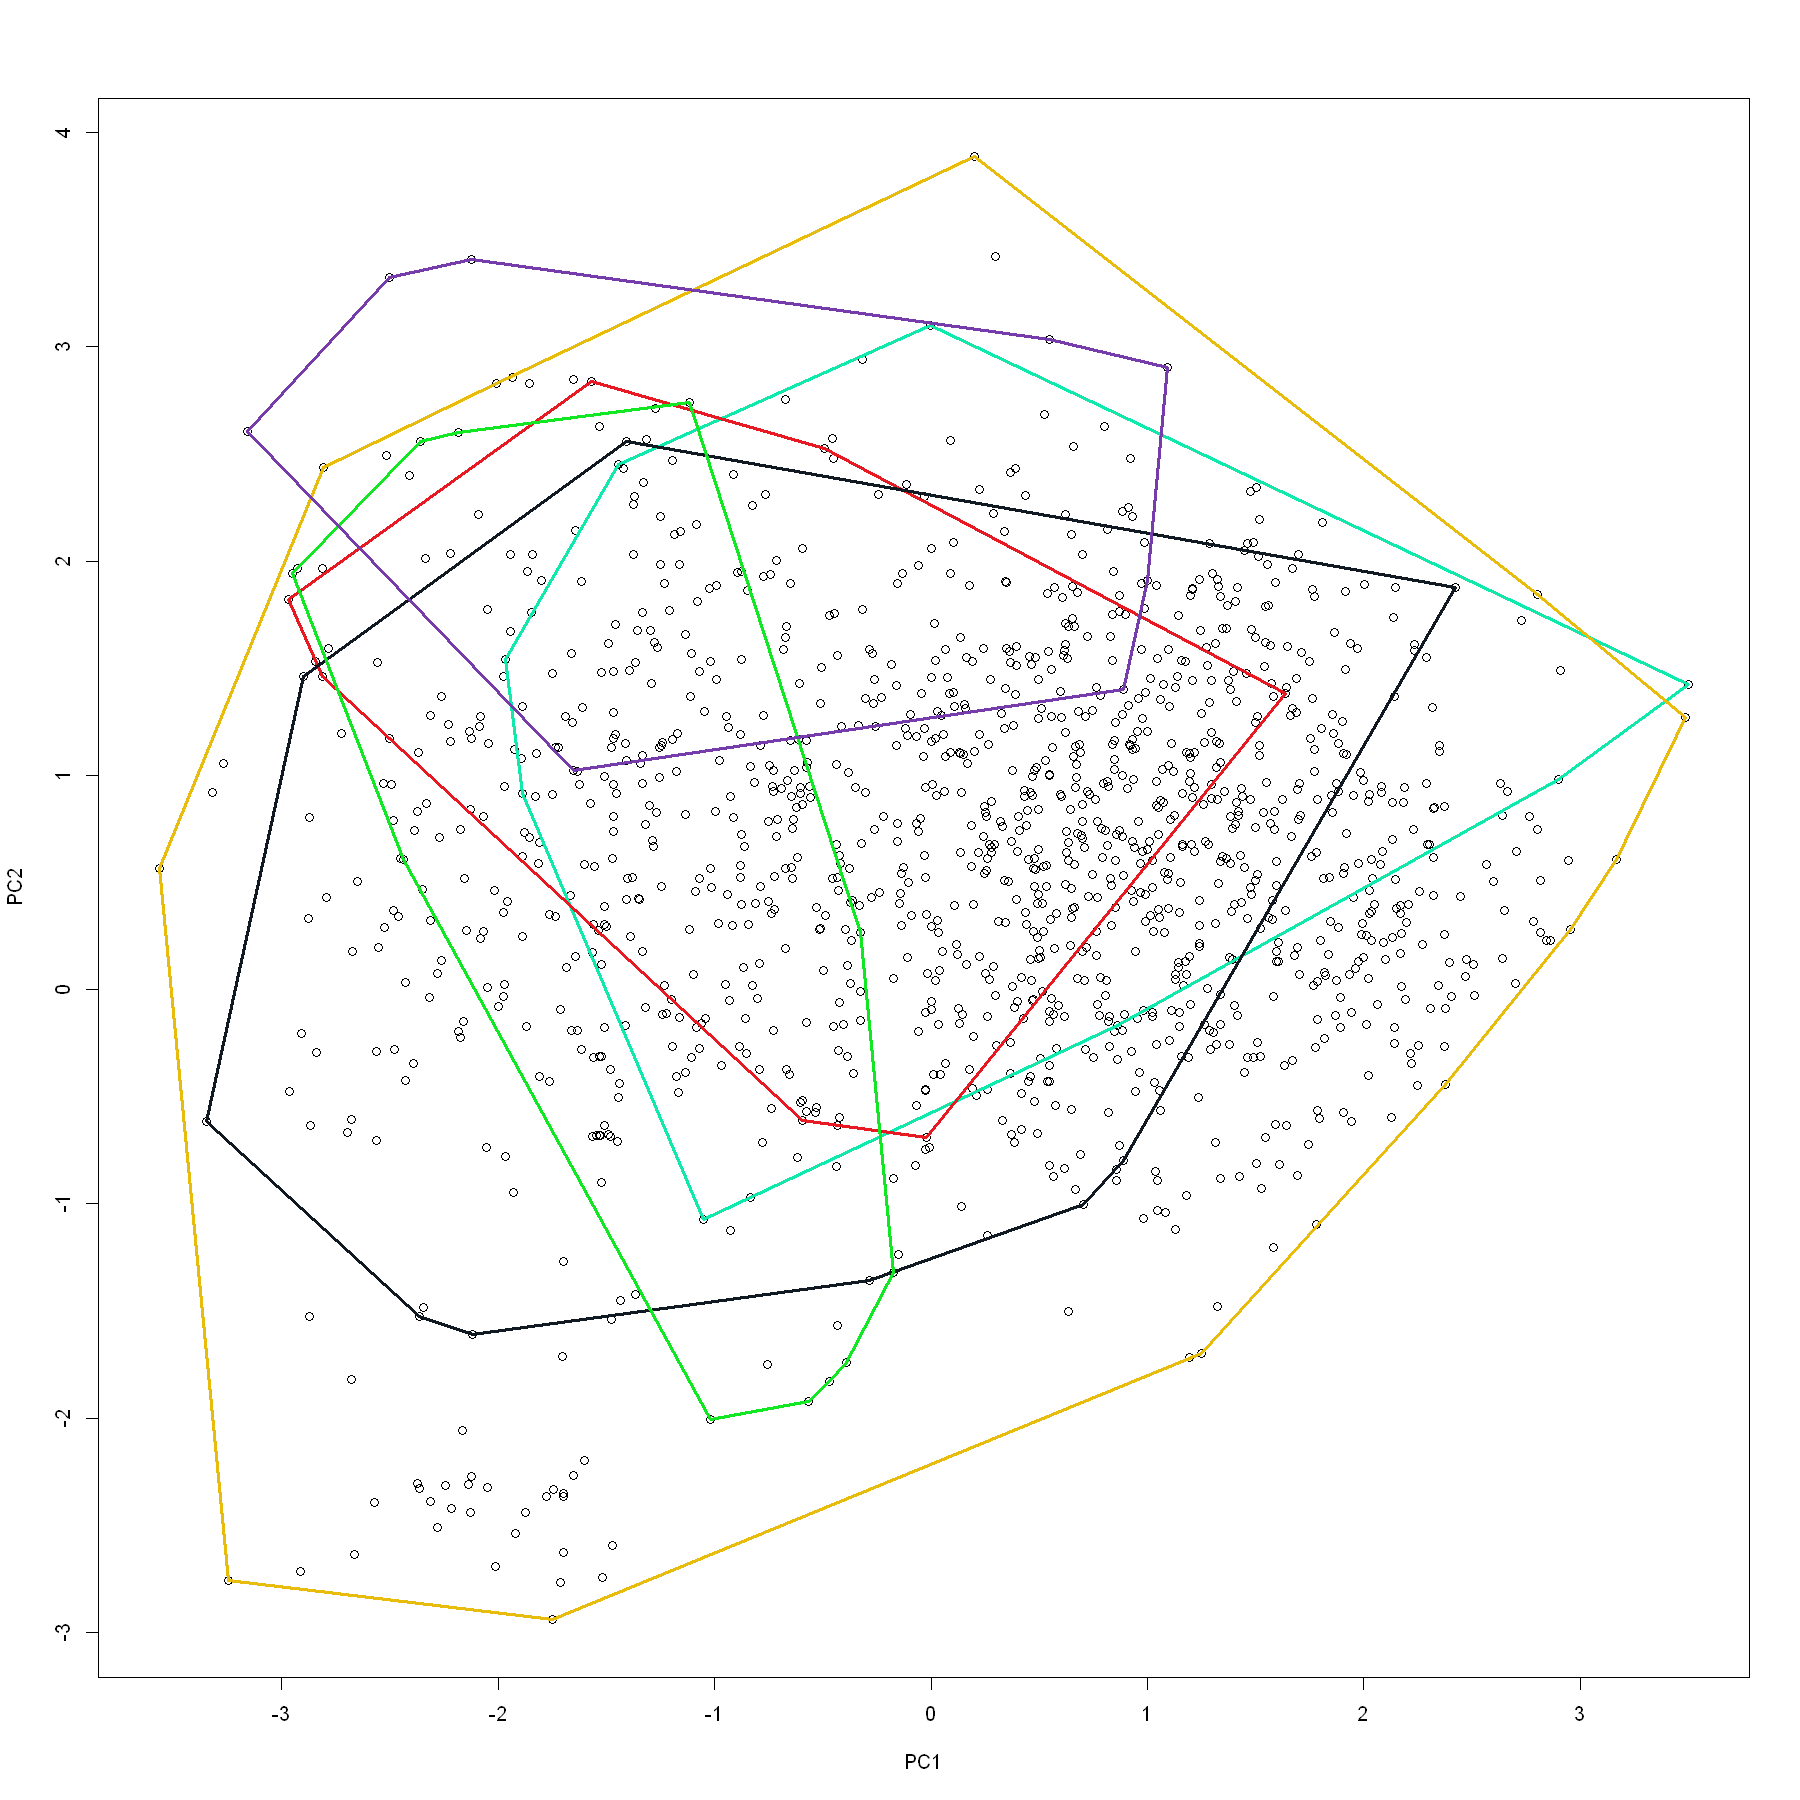

In [86]:
options(repr.plot.width = 15, repr.plot.height = 15)
colours <- c(AM = "#E7BC0C", EcM = "#11E8AB", ErM = "#763CAB", NM = "#11E823", NMAM = "#111A23", EcMAM = "#E71A23")

plot(ppca$PC1, ppca$PC2, xlab = "PC1", ylab = "PC2", pch = 21)

for (s in unique(ppca$state)){
    scores <- subset(ppca, state == s, select = c("PC1", "PC2")) # subset the dataframe to only include species of the choosen state
    # plotting convex hulls in R - https://chitchatr.wordpress.com/2011/12/30/convex-hull-around-scatter-plot-in-r/
    indices <- chull(x = scores$PC1, y = scores$PC2) # create the convex hull indices
    indices <- c(indices, indices[1])
    lines(scores$PC1[indices], scores$PC2[indices], col = colours[s], lwd = 2.5)
}

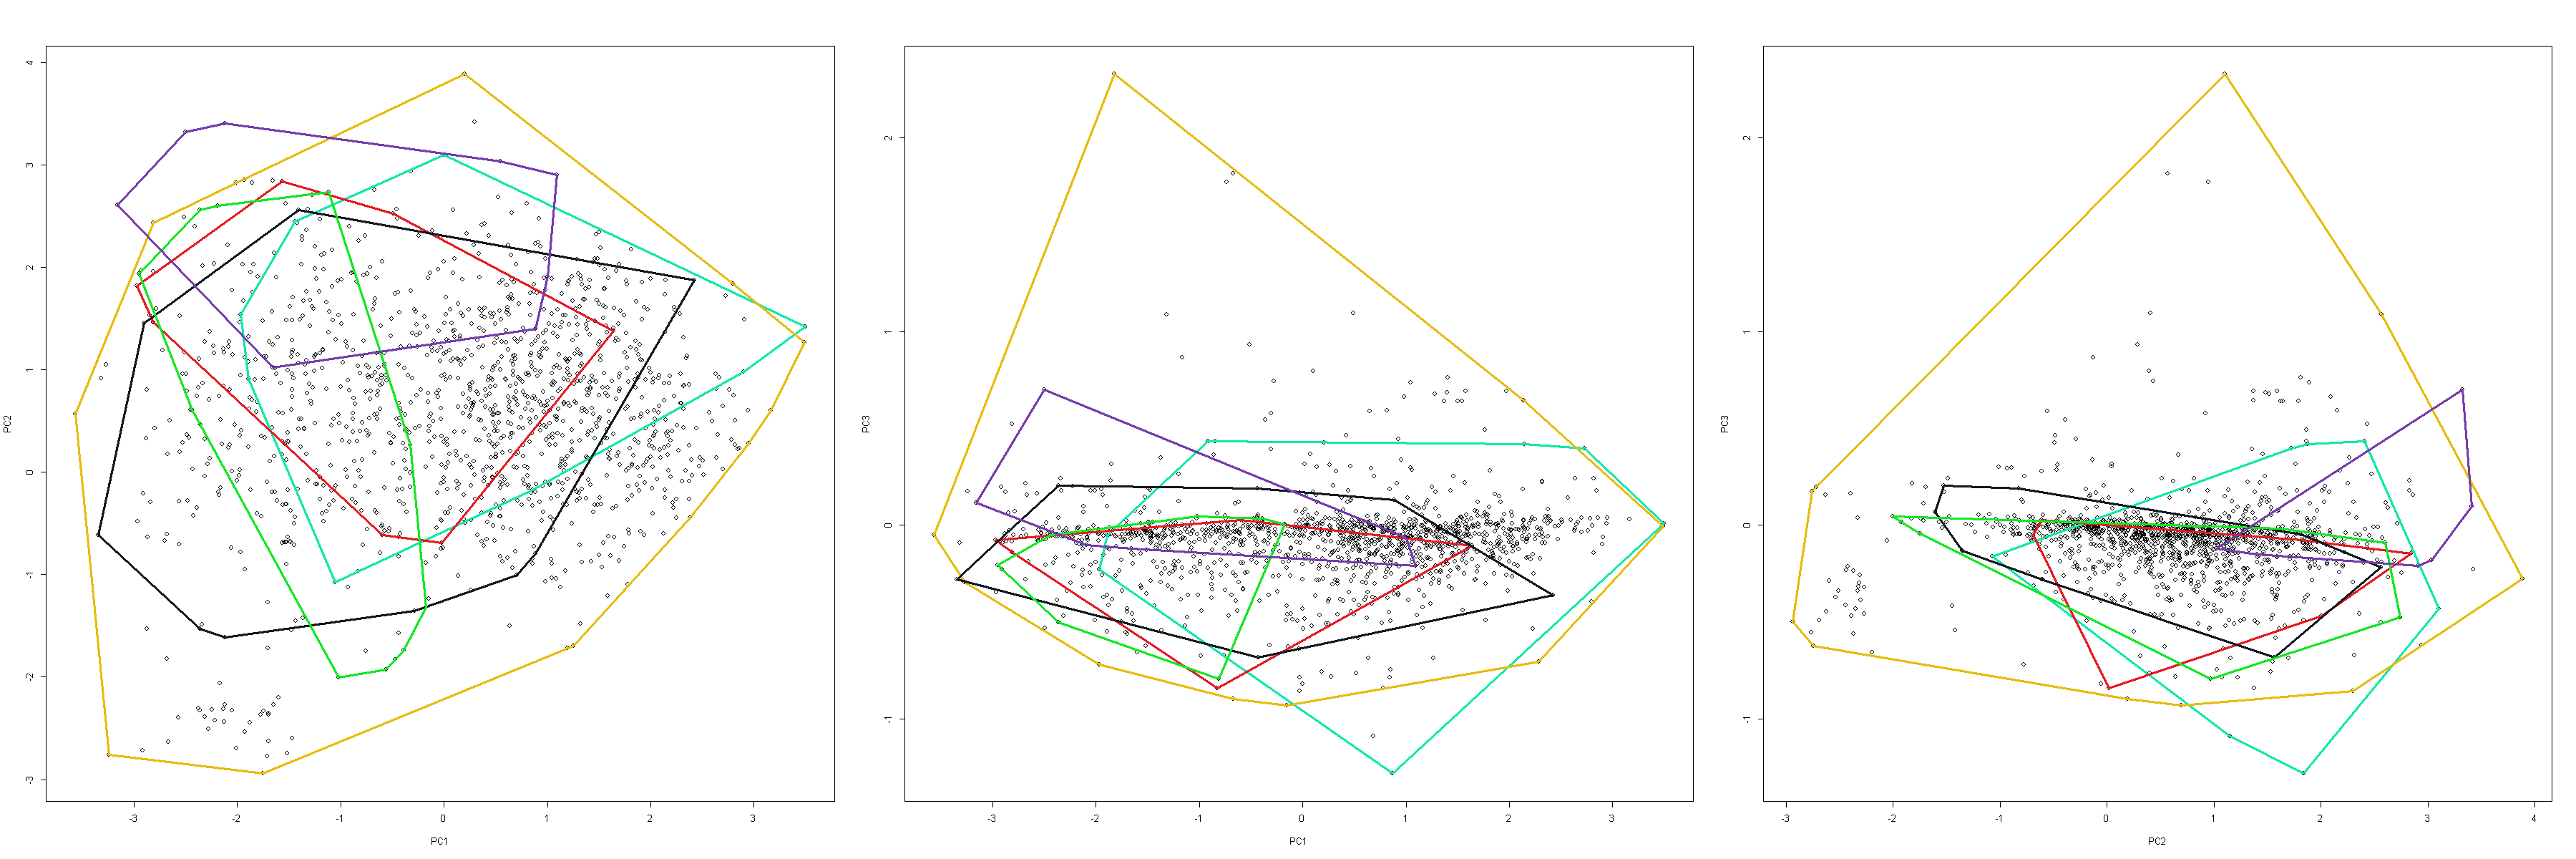

In [91]:
# try including all the 3 PCs

par(mfrow = c(1, 3))
options(repr.plot.width = 30, repr.plot.height = 10)

colours <- c(AM = "#E7BC0C", EcM = "#11E8AB", ErM = "#763CAB", NM = "#11E823", NMAM = "#111A23", EcMAM = "#E71A23")

plot(ppca$PC1, ppca$PC2, xlab = "PC1", ylab = "PC2", pch = 21)
for (s in unique(ppca$state)){
    scores <- subset(ppca, state == s, select = c("PC1", "PC2")) # subset the dataframe to only include species of the choosen state
    indices <- chull(x = scores$PC1, y = scores$PC2) # create the convex hull indices
    indices <- c(indices, indices[1])
    lines(scores$PC1[indices], scores$PC2[indices], col = colours[s], lwd = 2.5)
}

plot(ppca$PC1, ppca$PC3, xlab = "PC1", ylab = "PC3", pch = 21)
for (s in unique(ppca$state)){
    scores <- subset(ppca, state == s, select = c("PC1", "PC3")) # subset the dataframe to only include species of the choosen state
    indices <- chull(x = scores$PC1, y = scores$PC3) # create the convex hull indices
    indices <- c(indices, indices[1])
    lines(scores$PC1[indices], scores$PC3[indices], col = colours[s], lwd = 2.5)
}

plot(ppca$PC2, ppca$PC3, xlab = "PC2", ylab = "PC3", pch = 21)
for (s in unique(ppca$state)){
    scores <- subset(ppca, state == s, select = c("PC2", "PC3")) # subset the dataframe to only include species of the choosen state
    indices <- chull(x = scores$PC2, y = scores$PC3) # create the convex hull indices
    indices <- c(indices, indices[1])
    lines(scores$PC2[indices], scores$PC3[indices], col = colours[s], lwd = 2.5)
}

## ___`adephylo::ppca`___
---------------------------

In [87]:
# https://gist.github.com/sinarueeger/718c7ec3cee473ad0beed4feea4d0e24

averages_4d <- phylobase::phylo4d(x = phylogeny, tip.data = averages)
pcomps_v2 <- adephylo::ppca(x = averages_4d, center = FALSE, scale = FALSE, # our data has already been standardized, so these should be set to FALSE
                     method = "Abouheif", nfposi = 3, # nfposi - number of eigenvalues (number of PCs) - our data only has 3 variables so PCs cannot be > 3
                            scannf = FALSE) # read the docs to see what the args mean

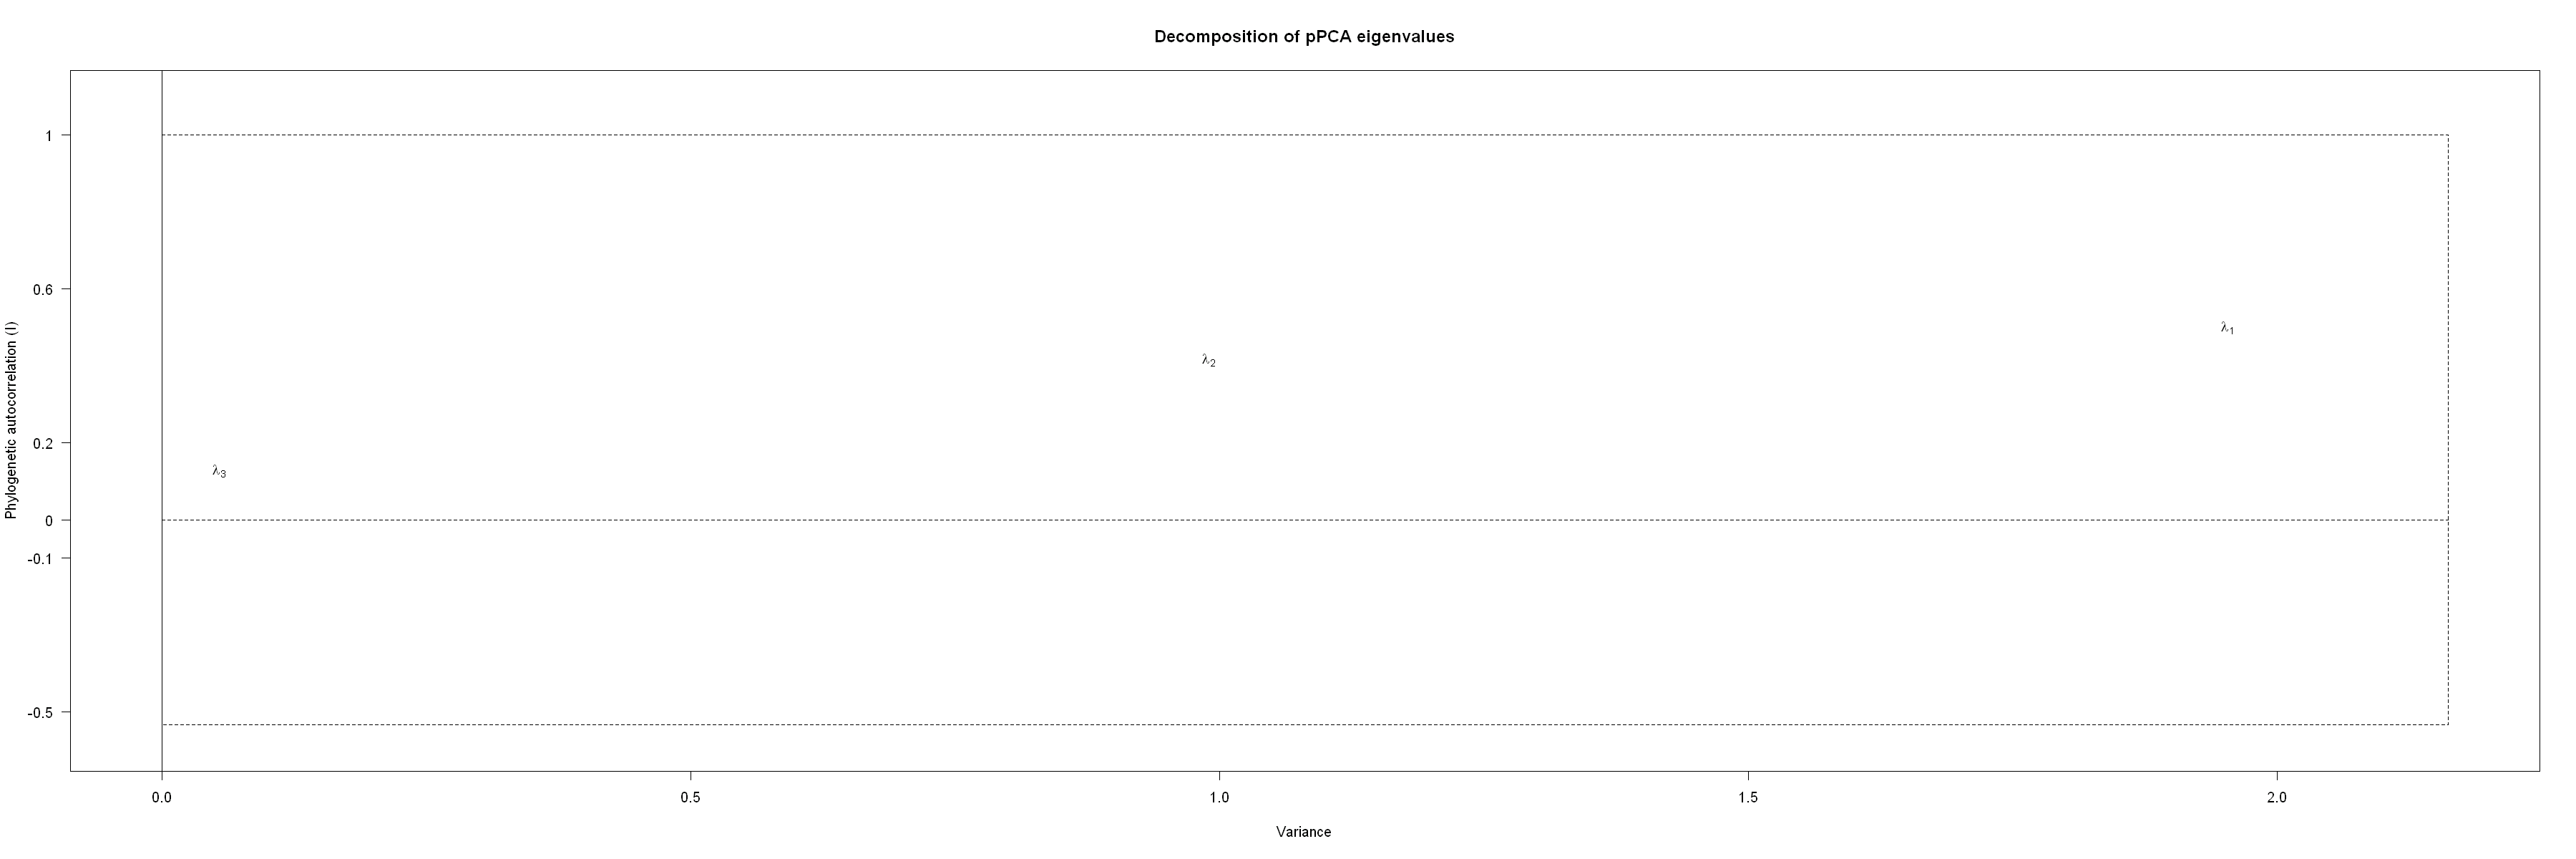

In [100]:
screeplot(pcomps_v2)

In [93]:
ppcs <- pcomps_v2$li
ppcs$binominal <- rownames(ppcs)
rownames(ppcs) <- NULL
ppcs <- merge(x = ppcs, y = states, by = "binominal")
head(ppcs)

,binominal,PC1,PC2,PC3,state
,<chr>,<dbl>,<dbl>,<dbl>,<chr>
1,Abies_alba,0.2142932,0.52884613,0.31884765,EcM
2,Abies_nephrolepis,0.1244893,-0.01885256,-0.05143545,EcM
3,Acacia_auriculiformis,0.1381405,0.13825816,0.38580803,EcMAM
4,Acacia_crassicarpa,-1.1773963,-1.27658639,0.21597000,EcMAM
5,Acacia_mangium,-1.1763500,-0.86274749,0.15907992,EcMAM
6,Acer_barbinerve,-1.9124577,-0.15257881,-0.02962873,AM


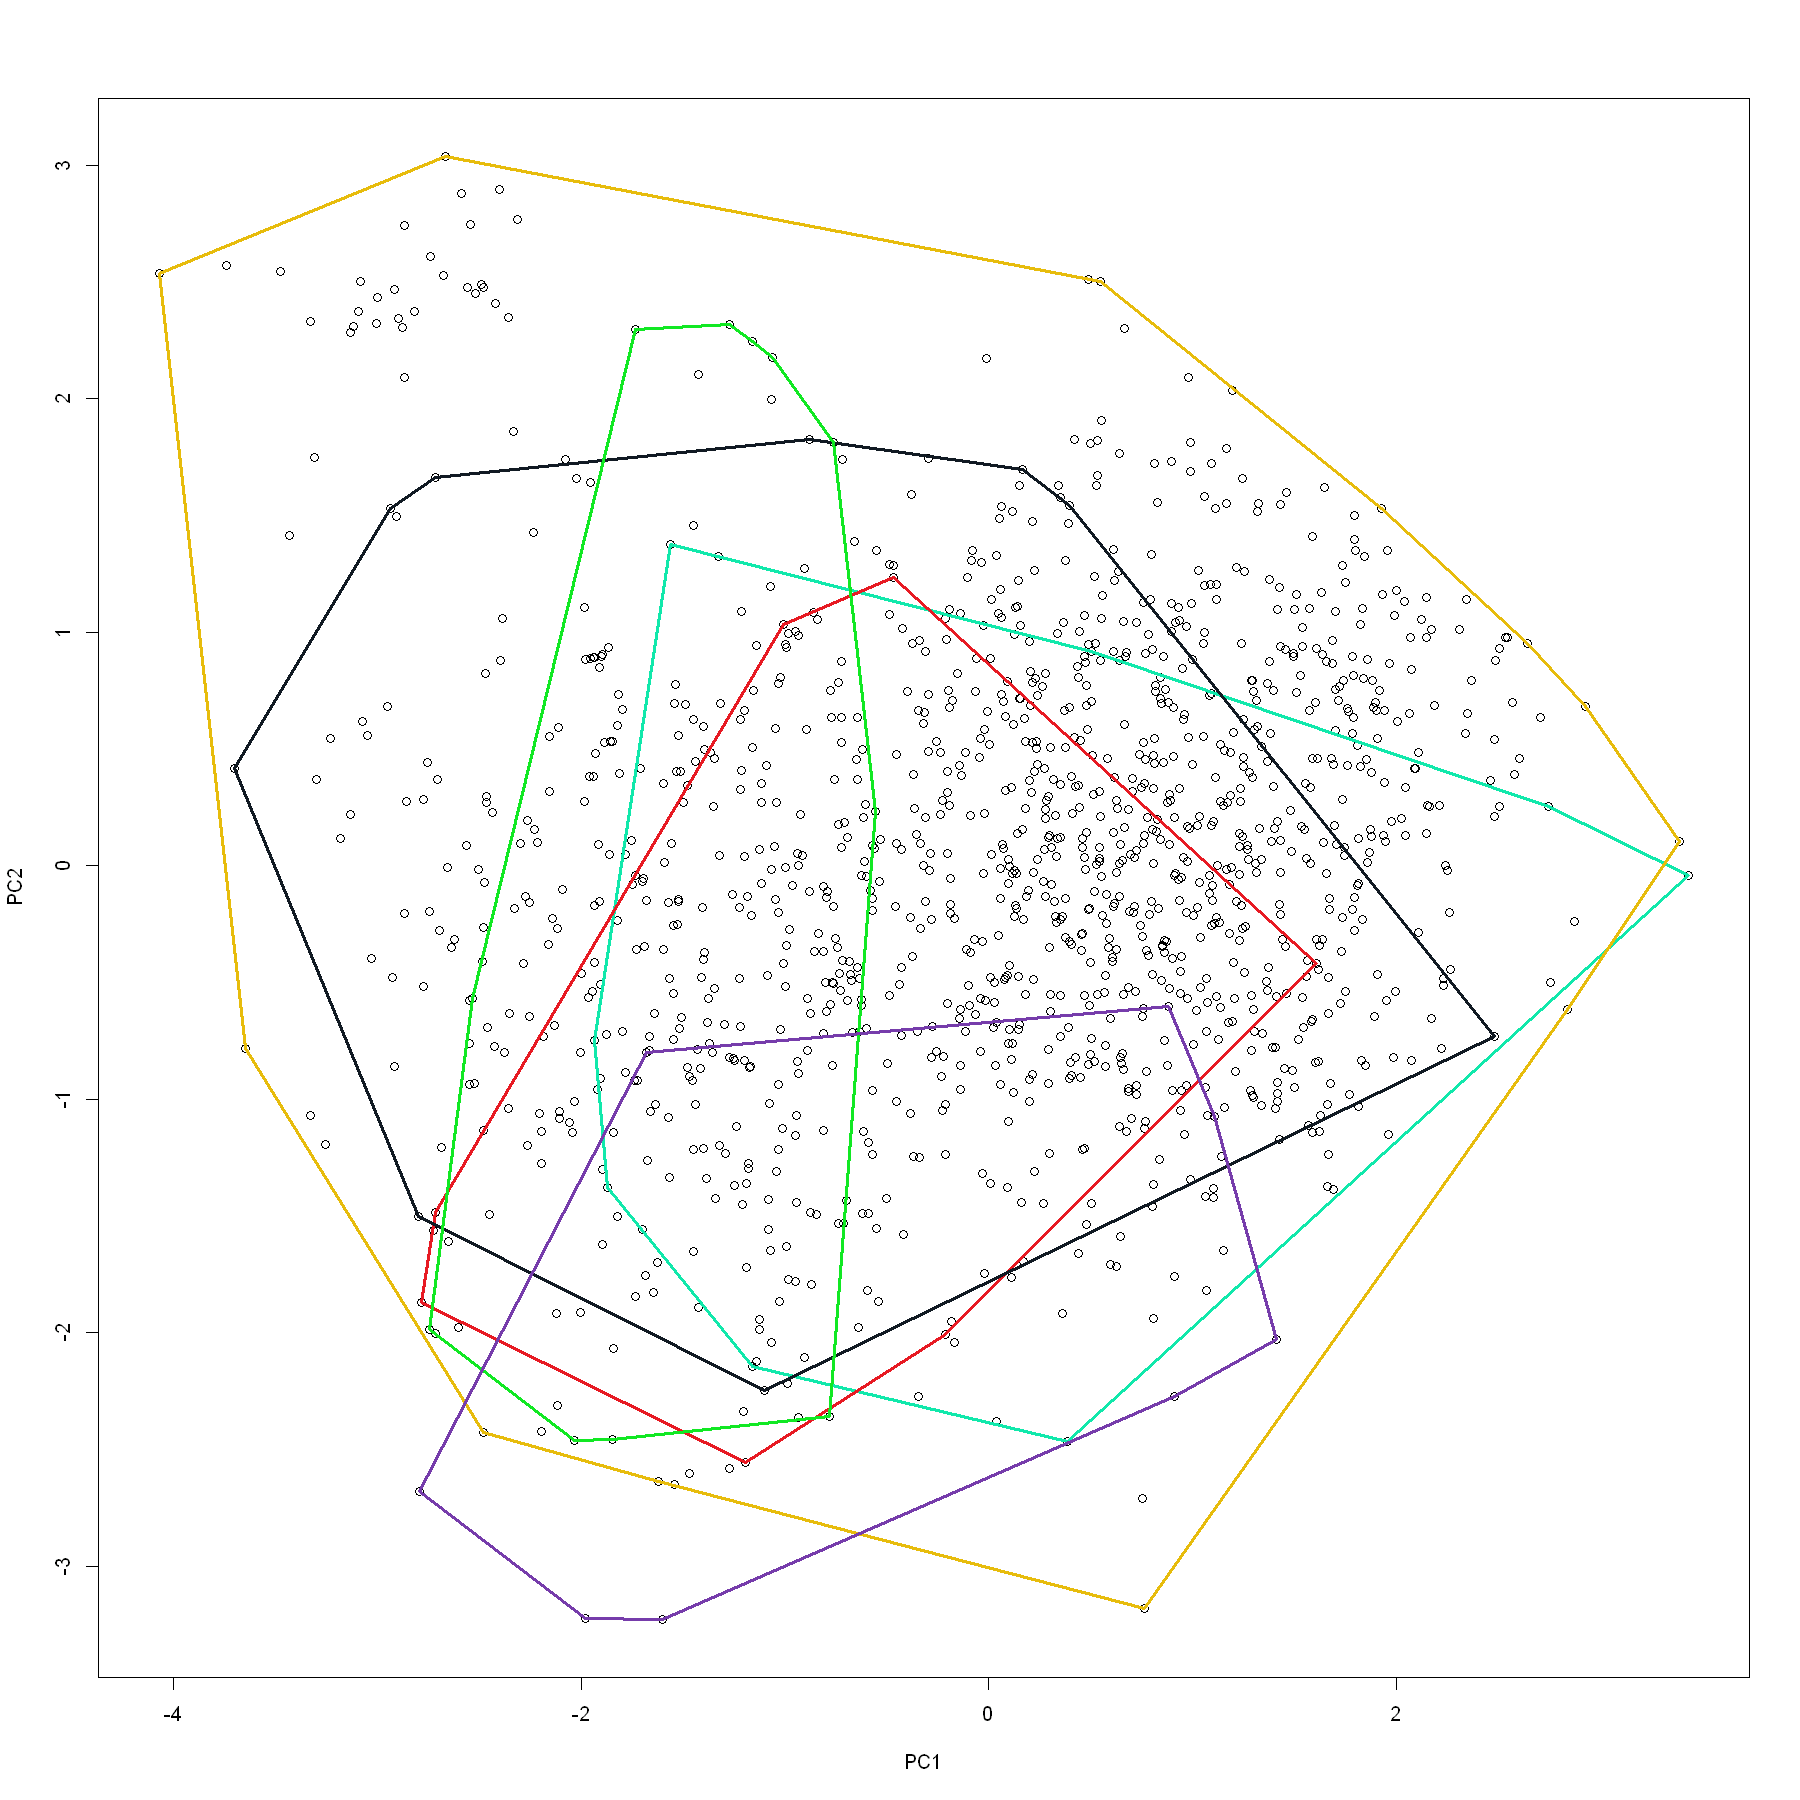

In [94]:
options(repr.plot.width = 15, repr.plot.height = 15)
colours <- c(AM = "#E7BC0C", EcM = "#11E8AB", ErM = "#763CAB", NM = "#11E823", NMAM = "#111A23", EcMAM = "#E71A23")

plot(ppcs$PC1, ppcs$PC2, xlab = "PC1", ylab = "PC2", pch = 21)

for (s in unique(ppcs$state)){
    scores <- subset(ppcs, state == s, select = c("PC1", "PC2")) # subset the dataframe to only include species of the choosen state
    indices <- chull(x = scores$PC1, y = scores$PC2) # create the convex hull indices
    indices <- c(indices, indices[1])
    lines(scores$PC1[indices], scores$PC2[indices], col = colours[s], lwd = 2.5)
}

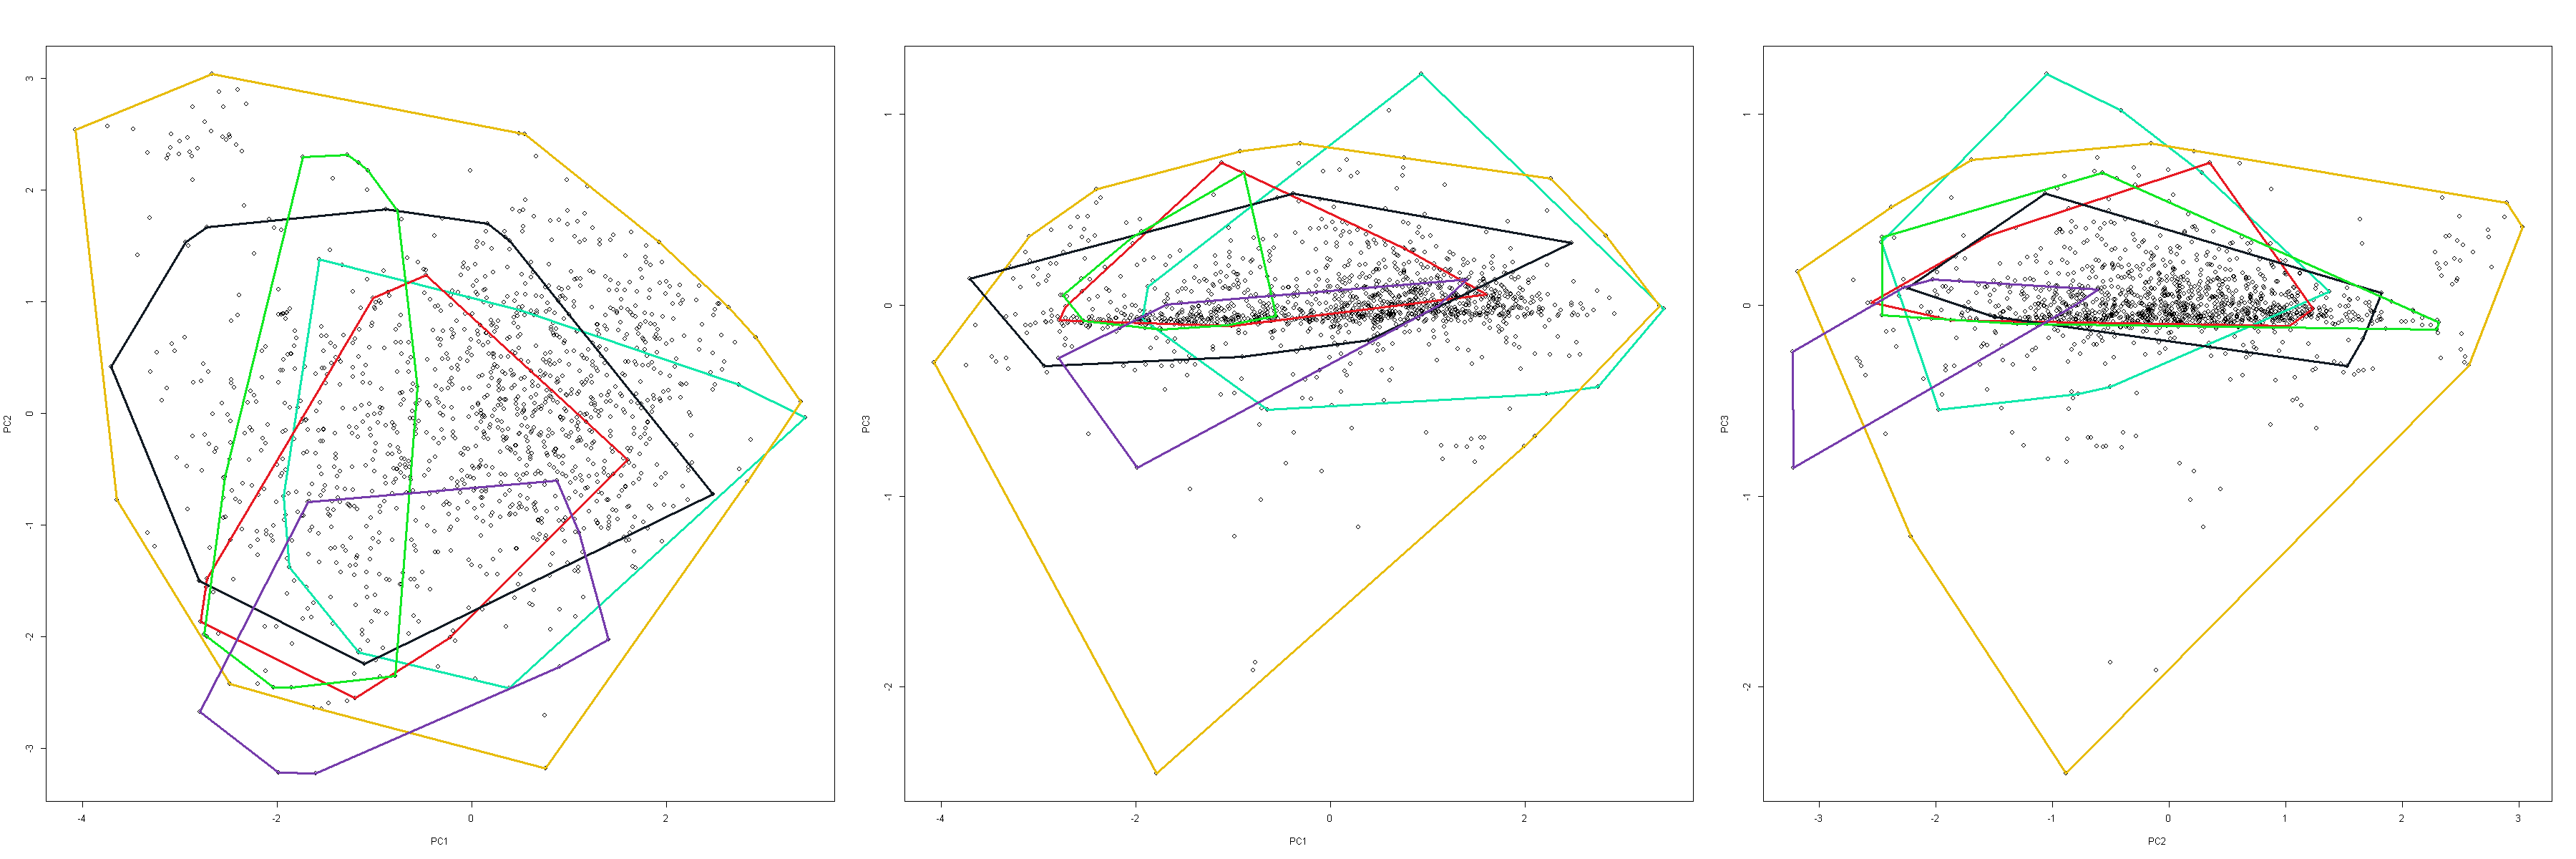

In [95]:
par(mfrow = c(1, 3))
options(repr.plot.width = 30, repr.plot.height = 10)

colours <- c(AM = "#E7BC0C", EcM = "#11E8AB", ErM = "#763CAB", NM = "#11E823", NMAM = "#111A23", EcMAM = "#E71A23")

plot(ppcs$PC1, ppcs$PC2, xlab = "PC1", ylab = "PC2", pch = 21)
for (s in unique(ppcs$state)){
    scores <- subset(ppcs, state == s, select = c("PC1", "PC2")) # subset the dataframe to only include species of the choosen state
    indices <- chull(x = scores$PC1, y = scores$PC2) # create the convex hull indices
    indices <- c(indices, indices[1])
    lines(scores$PC1[indices], scores$PC2[indices], col = colours[s], lwd = 2.5)
}

plot(ppcs$PC1, ppcs$PC3, xlab = "PC1", ylab = "PC3", pch = 21)
for (s in unique(ppcs$state)){
    scores <- subset(ppcs, state == s, select = c("PC1", "PC3")) # subset the dataframe to only include species of the choosen state
    indices <- chull(x = scores$PC1, y = scores$PC3) # create the convex hull indices
    indices <- c(indices, indices[1])
    lines(scores$PC1[indices], scores$PC3[indices], col = colours[s], lwd = 2.5)
}

plot(ppcs$PC2, ppcs$PC3, xlab = "PC2", ylab = "PC3", pch = 21)
for (s in unique(ppcs$state)){
    scores <- subset(ppcs, state == s, select = c("PC2", "PC3")) # subset the dataframe to only include species of the choosen state
    indices <- chull(x = scores$PC2, y = scores$PC3) # create the convex hull indices
    indices <- c(indices, indices[1])
    lines(scores$PC2[indices], scores$PC3[indices], col = colours[s], lwd = 2.5)
}